# Hunter-gatherer vs rural vs peri-urban gut microbiomes

| Section | Output |
| --- | --- |
| 3 | **Figure 3a** — number of SGBs per sample, hunter-gatherer vs rural, within each country |
| 3 | **Figure 3b** — number of SGBs per sample across the three Tanzanian lifestyles |
| 4 | **Figure 3c** — Jaccard PCoA of SGB presence/absence |
| 5 | **Figure 3d** — random-effects meta-analysis of SGB abundance between lifestyles |
| 6 | **Figure S9** — abundance of the SGBs separating the three Tanzanian lifestyles |

Three country blocks are compared: **CMR** (Cameroon), **PER-COL** (Peru and Colombia) and
**TZA** (Tanzania). Each contributes a hunter-gatherer and a rural group; Tanzania additionally
contributes the peri-urban Dar es Salaam samples, used in panel b and in Figure S9 only.

Panels a to d run on the **rarefied** profiles, so that neither richness, nor Jaccard distances,
nor the abundance meta-analysis are driven by sequencing depth. Figure S9 shows the unrarefied
relative abundances.

## 0. Setup

All inputs are collected here. `META_ANALYSIS_INPUT` is written by this notebook and
`META_ANALYSIS_RESULTS` is read back in, because the random-effects pooling itself runs outside
the notebook (section 5).

In [26]:
import math
import re
import statistics

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import seaborn as sns
import skbio
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse, Patch
from scipy.stats import mannwhitneyu
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa
from statannotations.Annotator import Annotator
from statsmodels.stats.multitest import fdrcorrection


METADATA = '../data/nw_metadata.tsv'
PROFILES = '../data/nw_profiles.tsv'                            # relative abundances
RAREFIED_PROFILES = '../data/rarefied_hg_r.tsv'                 # rarefied to the smallest library
RUBEL_METADATA = '../data/RubelMA_2020_metadata.tsv'
META_ANALYSIS_INPUT = '../data/hg_r.tsv'          # written here
META_ANALYSIS_RESULTS = '../data/hg_r_relab_metaa.tsv'
WNW_MODEL = '../data/nw_bayesian_model.tsv'                     # Westernized / non-Westernized model

COUNTRIES = ['CMR', 'PER-COL', 'TZA']
LIFESTYLES = ['Hunter-gatherer', 'Rural', 'Peri-urban']
LIFESTYLE_COLORS = {'Hunter-gatherer': '#43a230', 'Rural': '#cc9f63', 'Peri-urban': '#5875a4'}
COUNTRY_MARKERS = {'TZA': 'X', 'CMR': 'P', 'PER-COL': 'd'}

EFFECT_COLOR = '#4C72B0'        # pooled lifestyle effect
SIGNIF_COLOR = '#C44E52'        # per-country effect, significant
NONSIGNIF_COLOR = '#808080'     # per-country effect, not significant
CI_COLOR = '#C3C3C3'
ASSOCIATION_COLORS = {'ns': '#C0C0C0', 'NW': '#DEDE0E', 'W': '#2B8CBE'}
ASSOCIATION_LABELS = {'ns': 'Non-significant', 'NW': 'Non-Westernized associated',
                      'W': 'Westernized associated'}

ADULT_AGE = 16         # samples above this age are kept
Q_META = 0.005         # pooled q-value for inclusion in panel d
Q_COUNTRY = 0.2        # per-country q-value drawn as significant in panel d
Q_WNW = 0.2            # q-value of the W/NW model for the panel d colour strip
Q_TZA = 0.05           # q-value for the Tanzanian contrasts in Figure S9
TOP_PER_LIFESTYLE = 10 # SGBs shown per lifestyle in Figure S9

sns.set_theme(context='paper', style='ticks', font='DejaVu Sans')
mpl.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 10,
    'axes.grid': False, 'legend.frameon': False,
    'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42,
})

## 1. Metadata and profiles

Adults only. One study (`CM_china`) has no recorded age but contains adults exclusively, so it is
added back after the age filter; a single malformed age value becomes NaN and is dropped with it.

In [3]:
metadata = pd.read_table(METADATA).set_index('sample_id', drop=False)

adults_metadata = metadata.copy()
adults_metadata['age'] = pd.to_numeric(adults_metadata['age'], errors='coerce')
adults_metadata = adults_metadata[adults_metadata['age'] > ADULT_AGE]
china = metadata[(metadata['study_name'] == 'CM_china') & metadata['age'].isna()]
adults_metadata = pd.concat([adults_metadata, china])

print(f'{len(metadata)} samples in the metadata, {len(adults_metadata)} adults')

12870 samples in the metadata, 6900 adults


Both profile tables are restricted to the SGB-level rows and indexed by SGB identifier.
The columns of the rarefied table carry a suffix added by the rarefaction step, which is stripped.
The full lineages are kept aside, since the taxonomy is needed later to label the SGBs.

In [4]:
def sgb_profiles(path, strip_column_suffix=0):
    """Read a MetaPhlAn table, keep the SGB rows, index them by SGB id, return the lineages too."""
    table = pd.read_table(path, index_col=0)
    if strip_column_suffix:
        table.columns = [column[:-strip_column_suffix] for column in table.columns]
    table = table.loc[[clade for clade in table.index if 't__' in clade]]
    lineages = list(table.index)
    table.index = [clade.split('|')[-1][3:] for clade in lineages]
    return table, lineages


profiles, lineages = sgb_profiles(PROFILES)
rarefied, _ = sgb_profiles(RAREFIED_PROFILES, strip_column_suffix=3)

print(f'relative abundances: {profiles.shape[0]} SGBs x {profiles.shape[1]} samples')
print(f'rarefied:            {rarefied.shape[0]} SGBs x {rarefied.shape[1]} samples')

relative abundances: 4892 SGBs x 12870 samples
rarefied:            1976 SGBs x 765 samples


Labels for the SGBs. An SGB with a named species becomes `Species name (SGBxxxx)`; one known only
from metagenomes (a `GGB...` placeholder genus, or `..._unclassified`) becomes the lowest *named*
rank followed by the SGB identifier, which is how the published panels label them.

In [5]:
PLACEHOLDER = re.compile(r'^(GGB|FGB|OFGB|CFGB|PFGB)\d')


def taxonomy_table(lineages):
    """One row per SGB, one column per rank prefix (k__, p__, ..., t__)."""
    rows = {}
    for lineage in lineages:
        ranks = {clade[:3]: clade[3:] for clade in lineage.split('|')}
        rows[ranks['t__']] = ranks
    return pd.DataFrame(rows).T


def is_named(name):
    return bool(name) and 'unclassified' not in name and not PLACEHOLDER.match(name)


def sgb_label(sgb, taxonomy):
    if sgb not in taxonomy.index:
        return sgb
    species = taxonomy.loc[sgb, 's__']
    if is_named(species):
        return f"{species.replace('_', ' ')} ({sgb})"
    for rank in ('g__', 'f__', 'o__', 'c__', 'p__'):   # fall back to the lowest named rank
        name = taxonomy.loc[sgb, rank]
        if is_named(name):
            return f"{name.replace('_', ' ')} {sgb}"
    return sgb


taxonomy = taxonomy_table(lineages)
LABELS = {sgb: sgb_label(sgb, taxonomy) for sgb in taxonomy.index}

pd.Series({sgb: LABELS[sgb] for sgb in ['SGB1934', 'SGB15171', 'SGB6291', 'SGB13959']},
          name='label').to_frame()

,label
SGB1934,Parabacteroides distasonis (SGB1934)
SGB15171,Ruminococcaceae SGB15171
SGB6291,Clostridia SGB6291
SGB13959,Firmicutes SGB13959


## 2. Lifestyle groups

The groups follow the sampling design of the contributing studies:

**Hunter-gatherer**

* `SmitsSA_2017` (40 Hadza, TZA) and `RampelliS_2015` (Hadza, TZA)
* `Obregon-TitoAJ_2015` — the Matses samples (ids starting with `SM`), PER
* `RubelMA_2020` — the Baka and Bagyeli subjects, taken from the study's own `lifestyle` column, CMR
* `LokmerA_2019` — the BaAka subjects (ids starting with `BAB`), CMR

**Rural**

* `Obregon-TitoAJ_2015` — the Tunapuco samples (`HC`), plus the Colombian rural samples (`COL`)
* `RubelMA_2020` — the Mbororo Fulani and Bantu pastoralists and agropastoralists, CMR
* `LokmerA_2019` — the agriculturalist and fisher subjects, CMR
* `CM_tanzania` and `CM_tanzania2` — the rural non-Westernized TZA samples

**Peri-urban**

* `CM_tanzania_TB_DAR` — Dar es Salaam, TZA

In [6]:
# PER-COL
per_samples = adults_metadata[adults_metadata['study_name'].isin(['CM_colombia',
                                                                 'Obregon-TitoAJ_2015'])]
per_samples = per_samples[per_samples['country'].isin(['COL', 'PER'])]
per_hg = [s for s in per_samples.index if s.startswith('SM')]
per_rural = [s for s in per_samples.index if s.startswith(('HC', 'COL'))]

# CMR: RubelMA_2020 carries its own lifestyle column, LokmerA_2019 is split on the subject id
rubel = pd.read_table(RUBEL_METADATA).set_index('sample_id')
rubel_hg = set(rubel.index[rubel['lifestyle'] == 'Hunter-gatherer'])

cmr_samples = adults_metadata[adults_metadata['study_name'].isin(['RubelMA_2020', 'LokmerA_2019'])]
cmr_samples = cmr_samples[cmr_samples['country'] == 'CMR']
lokmer = cmr_samples[cmr_samples['study_name'] == 'LokmerA_2019']
cmr_hg = [s for s in lokmer.index if lokmer.loc[s, 'subject_id'].startswith('BAB')]
cmr_hg += [s for s in cmr_samples.index[cmr_samples['study_name'] == 'RubelMA_2020']
           if s in rubel_hg]
cmr_rural = [s for s in cmr_samples.index if s not in cmr_hg]

# TZA
tza_samples = adults_metadata[adults_metadata['country'] == 'TZA']
tza_hg = list(tza_samples.index[tza_samples['study_name'].isin(['SmitsSA_2017', 'RampelliS_2015'])])
tza_rural = list(tza_samples.index[tza_samples['study_name'].isin(['CM_tanzania', 'CM_tanzania2'])])
tza_periurban = list(tza_samples.index[tza_samples['study_name'] == 'CM_tanzania_TB_DAR'])

MEMBERSHIP = {
    ('CMR', 'Hunter-gatherer'): cmr_hg, ('CMR', 'Rural'): cmr_rural,
    ('PER-COL', 'Hunter-gatherer'): per_hg, ('PER-COL', 'Rural'): per_rural,
    ('TZA', 'Hunter-gatherer'): tza_hg, ('TZA', 'Rural'): tza_rural,
    ('TZA', 'Peri-urban'): tza_periurban,
}

One tidy frame holds the country and lifestyle of every sample, restricted to those that passed the
adult filter and that have both a rarefied and an unrarefied profile. Everything below is indexed
off it, which keeps samples, colours and group labels aligned without parallel lists.

In [7]:
groups = pd.concat([
    pd.DataFrame({'country': country, 'lifestyle': lifestyle},
                 index=pd.Index(samples, name='sample_id'))
    for (country, lifestyle), samples in MEMBERSHIP.items()
])
groups = groups[~groups.index.duplicated()]
groups = groups.loc[[s for s in groups.index
                     if s in rarefied.columns and s in profiles.columns]]
groups['country'] = pd.Categorical(groups['country'], COUNTRIES)
groups['lifestyle'] = pd.Categorical(groups['lifestyle'], LIFESTYLES)

# Presence / absence of every SGB in every sample, from the rarefied profiles.
presence = (rarefied[groups.index] > 0).astype(int).T

groups.groupby(['country', 'lifestyle'], observed=False).size().unstack().fillna(0).astype(int)

lifestyle,Hunter-gatherer,Rural,Peri-urban
country,,,
CMR,21,118,0
PER-COL,10,17,0
TZA,39,98,217


## 3. Figures 3a and 3b — number of SGBs per sample

Richness is the number of SGBs detected in a rarefied profile, so the comparison is not confounded
by sequencing depth. Groups are compared with a two-sided Mann-Whitney U test.

In [8]:
richness = groups.copy()
richness['SGBs'] = presence.sum(axis=1)
richness.groupby(['country', 'lifestyle'], observed=True)['SGBs'].describe()[['count', 'mean', '50%']]

count        mean    50%
country lifestyle                                
CMR     Hunter-gatherer   21.0  117.000000  122.0
        Rural            118.0  106.406780  104.0
PER-COL Hunter-gatherer   10.0  160.000000  167.5
        Rural             17.0  171.529412  190.0
TZA     Hunter-gatherer   39.0  198.128205  205.0
        Rural             98.0  127.724490  128.5
        Peri-urban       217.0   91.336406   88.0

PER-COL_Hunter-gatherer vs. PER-COL_Rural: Mann-Whitney-Wilcoxon test two-sided, P_val:1.596e-01 U_stat=5.650e+01
CMR_Hunter-gatherer vs. CMR_Rural: Mann-Whitney-Wilcoxon test two-sided, P_val:2.008e-01 U_stat=1.457e+03
TZA_Hunter-gatherer vs. TZA_Rural: Mann-Whitney-Wilcoxon test two-sided, P_val:5.160e-11 U_stat=3.288e+03


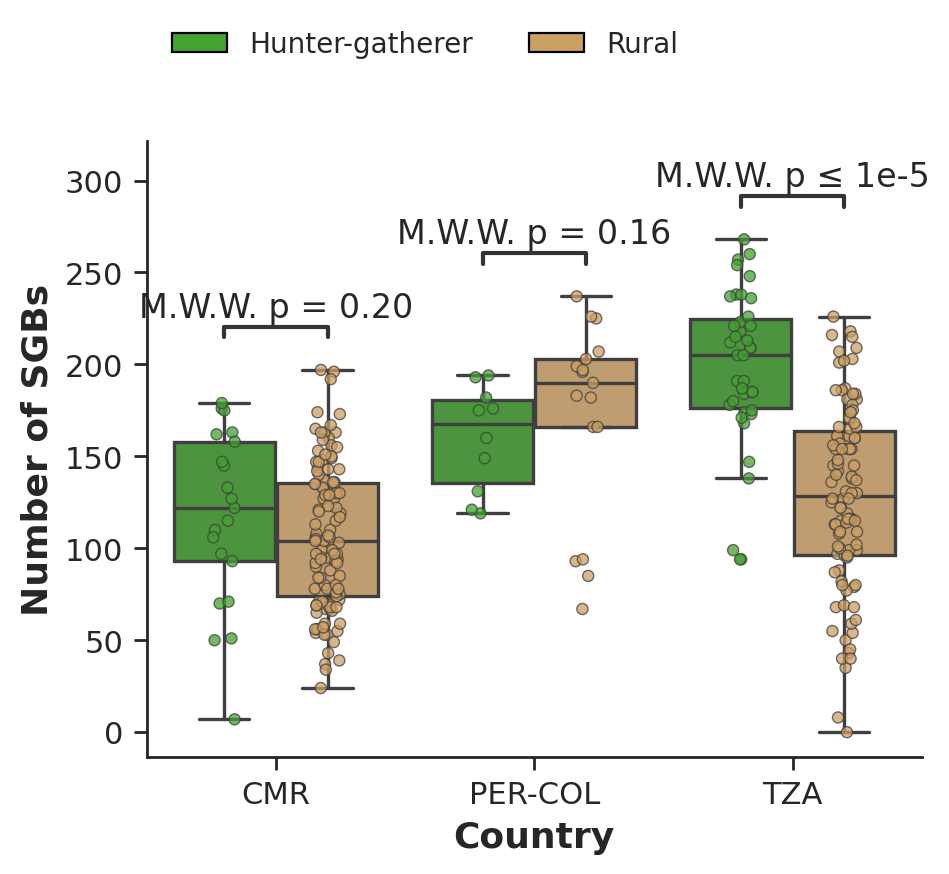

In [10]:
# Figure 3a — hunter-gatherer vs rural within each country
hg_rural = richness[richness['lifestyle'] != 'Peri-urban']
hue_order = ['Hunter-gatherer', 'Rural']
palette = [LIFESTYLE_COLORS[lifestyle] for lifestyle in hue_order]

plot_params = dict(data=hg_rural, x='country', y='SGBs', hue='lifestyle',
                   order=COUNTRIES, hue_order=hue_order)
pairs = [[(country, 'Hunter-gatherer'), (country, 'Rural')] for country in COUNTRIES]

fig, ax = plt.subplots(figsize=(5, 4), dpi=200)
sns.boxplot(**plot_params, palette=palette, showfliers=False, linewidth=1.2, ax=ax)
Annotator(ax, pairs, **plot_params).configure(test='Mann-Whitney',
                                              text_format='simple').apply_and_annotate()
sns.stripplot(**plot_params, palette=palette, dodge=True, linewidth=0.5, alpha=0.75, size=4, ax=ax)

ax.set_xlabel('Country', fontweight='bold')
ax.set_ylabel('Number of SGBs', fontweight='bold')
ax.legend(handles=[Patch(facecolor=LIFESTYLE_COLORS[k], edgecolor='black', label=k)
                   for k in hue_order],
          loc='upper left', bbox_to_anchor=(0, 1.22), ncol=2)
sns.despine()
plt.show()

Hunter-gatherer vs. Rural: Mann-Whitney-Wilcoxon test two-sided, P_val:5.160e-11 U_stat=3.288e+03
Rural vs. Peri-urban: Mann-Whitney-Wilcoxon test two-sided, P_val:2.753e-11 U_stat=1.562e+04
Hunter-gatherer vs. Peri-urban: Mann-Whitney-Wilcoxon test two-sided, P_val:2.114e-20 U_stat=8.172e+03


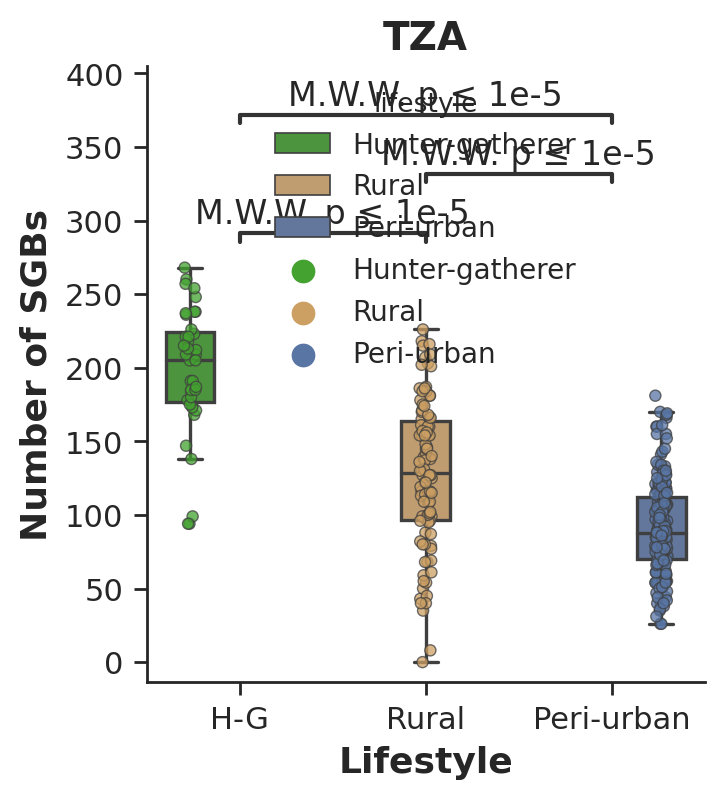

In [17]:
# Figure 3b — the three Tanzanian lifestyles
tza_richness = richness[richness['country'] == 'TZA']

plot_params = dict(data=tza_richness, x='lifestyle', y='SGBs', order=LIFESTYLES)
pairs = [('Hunter-gatherer', 'Rural'), ('Hunter-gatherer', 'Peri-urban'),
         ('Rural', 'Peri-urban')]
palette = [LIFESTYLE_COLORS[lifestyle] for lifestyle in LIFESTYLES]

fig, ax = plt.subplots(figsize=(3.6, 4), dpi=200)
sns.boxplot(**plot_params, hue='lifestyle', palette=palette, showfliers=False, linewidth=1.2, ax=ax)
Annotator(ax, pairs, **plot_params).configure(test='Mann-Whitney',
                                              text_format='simple').apply_and_annotate()
sns.stripplot(**plot_params, hue='lifestyle', palette=palette, linewidth=0.5, alpha=0.75, size=4, ax=ax, dodge=True)

ax.set_title('TZA', fontweight='bold')
ax.set_xlabel('Lifestyle', fontweight='bold')
ax.set_ylabel('Number of SGBs', fontweight='bold')
ax.set_xticks(range(len(LIFESTYLES)))
ax.set_xticklabels(['H-G', 'Rural', 'Peri-urban'])
sns.despine()
plt.show()

## 4. Figure 3c — Jaccard PCoA

Jaccard distances on SGB presence/absence over the hunter-gatherer and rural samples of all three
countries; the peri-urban samples are not part of this ordination. Marker shape encodes country,
colour encodes lifestyle, and each ellipse covers two standard deviations of one lifestyle cloud.

In [18]:
def confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    """Covariance confidence ellipse of x and y, drawn into ax."""
    covariance = np.cov(x, y)
    pearson = covariance[0, 1] / np.sqrt(covariance[0, 0] * covariance[1, 1])
    ellipse = Ellipse((0, 0), width=2 * np.sqrt(1 + pearson), height=2 * np.sqrt(1 - pearson),
                      facecolor=facecolor, **kwargs)
    transform = (transforms.Affine2D()
                 .rotate_deg(45)
                 .scale(np.sqrt(covariance[0, 0]) * n_std, np.sqrt(covariance[1, 1]) * n_std)
                 .translate(np.mean(x), np.mean(y)))
    ellipse.set_transform(transform + ax.transData)
    return ax.add_patch(ellipse)

In [19]:
ordination_samples = groups[groups['lifestyle'] != 'Peri-urban']
pa = presence.loc[ordination_samples.index]
pa = pa.loc[:, pa.sum() > 0]

jaccard = beta_diversity('jaccard', pa.values, ids=list(pa.index))
ordination = pcoa(jaccard)

permanova = skbio.stats.distance.permanova(
    jaccard, ordination_samples['lifestyle'].astype(str).tolist(), permutations=999)
f_statistic, n, k = permanova['test statistic'], permanova['sample size'], permanova['number of groups']
print(f"PERMANOVA on lifestyle: pseudo-F = {f_statistic:.2f}, p = {permanova['p-value']:.3f}, "
      f"R2 = {1 - 1 / (1 + f_statistic * (k - 1) / (n - k)):.3f}")

/shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/miniconda3/envs/wnw/lib/python3.8/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:146: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -0.016824123356031354 and the largest is 9.152977846705449.
  warn(


PERMANOVA on lifestyle: pseudo-F = 9.28, p = 0.001, R2 = 0.030


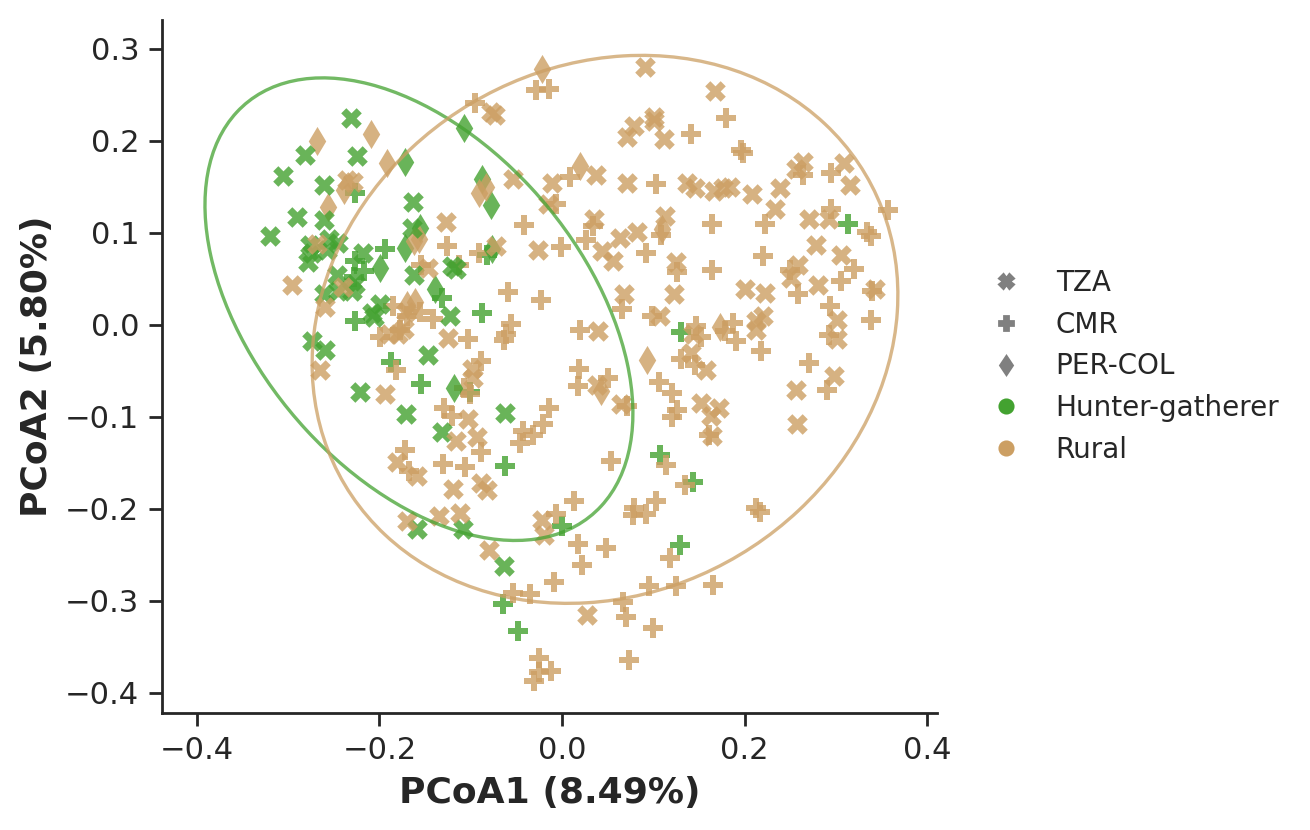

In [20]:
coordinates = ordination.samples[['PC1', 'PC2']].join(ordination_samples)
explained = 100 * ordination.proportion_explained

fig, ax = plt.subplots(figsize=(5, 4.5), dpi=200)
for (country, lifestyle), subset in coordinates.groupby(['country', 'lifestyle'], observed=True):
    ax.scatter(subset['PC1'], subset['PC2'], marker=COUNTRY_MARKERS[country], s=55, alpha=0.8,
               linewidths=0, color=LIFESTYLE_COLORS[lifestyle], rasterized=True)

for lifestyle in ('Hunter-gatherer', 'Rural'):
    cloud = coordinates[coordinates['lifestyle'] == lifestyle]
    confidence_ellipse(cloud['PC1'].values, cloud['PC2'].values, ax,
                       edgecolor=LIFESTYLE_COLORS[lifestyle], alpha=0.75, linewidth=1.2)

ax.set_xlabel(f'PCoA1 ({explained["PC1"]:.2f}%)', fontweight='bold')
ax.set_ylabel(f'PCoA2 ({explained["PC2"]:.2f}%)', fontweight='bold')
ax.legend(handles=[Line2D([], [], linestyle='', marker=COUNTRY_MARKERS[c],
                          color=NONSIGNIF_COLOR, label=c) for c in ['TZA', 'CMR', 'PER-COL']]
                  + [Line2D([], [], linestyle='', marker='o', color=LIFESTYLE_COLORS[l], label=l)
                     for l in ('Hunter-gatherer', 'Rural')],
          loc='center left', bbox_to_anchor=(1.02, 0.5))
sns.despine()
plt.show()

## 5. Figure 3d — meta-analysis of SGB abundance between lifestyles

### 5.1 Input table

Rarefied abundances are arcsine square-root transformed and written out together with the
covariates. The meta-analysis itself runs outside the notebook: within each country a standardized
mean difference between hunter-gatherer and rural samples is estimated, adjusted for age, gender
and sequencing depth, and the three per-country estimates are pooled with a DerSimonian-Laird
random-effects model.

In the results table a **positive** effect means the SGB is more abundant in rural samples.

In [21]:
def arcsinsqrt(x):
    return np.arcsin(np.sqrt(x / 100))


model_samples = ordination_samples.index                 # hunter-gatherer and rural only
model_input = rarefied[model_samples]
model_input = model_input.loc[model_input.sum(axis=1) > 0].apply(arcsinsqrt)
model_input.index = ['t__' + sgb for sgb in model_input.index]

covariates = metadata.loc[model_samples, ['gender', 'age', 'number_reads']].T
covariates.loc['lifestyle'] = ordination_samples['lifestyle'].astype(str)
covariates.loc['country'] = ordination_samples['country'].astype(str)

pd.concat([covariates, model_input]).to_csv(META_ANALYSIS_INPUT, sep='\t')
print(f'{model_input.shape[0]} SGBs x {model_input.shape[1]} samples -> {META_ANALYSIS_INPUT}')

1434 SGBs x 303 samples -> ../data/hg_r.tsv


### 5.2 Results and lifestyle association

The results table carries an effect, standard error, p-value and q-value per country (`TZA_`,
`CMR_`, `PER_`) and the pooled random-effects columns (`RE_`). The rows of the panel are the SGBs
whose pooled q-value is below 0.005, sorted by effect size.

The colour strip on the left of the panel comes from a separate model of Westernized versus
non-Westernized samples: grey where that model found no association (q >= 0.2), yellow where the
SGB is non-Westernized associated (positive z-score), blue where it is Westernized associated.

In [22]:
results = pd.read_table(META_ANALYSIS_RESULTS, index_col=0)
results.index = [sgb[3:] for sgb in results.index]                 # drop the t__ prefix

selected = results[results['RE_Effect_Qvalue'] < Q_META].sort_values('RE_Effect', ascending=False)
selected[['ci_low', 'ci_high']] = (selected['RE_conf_int'].str.split(';', expand=True)
                                   .astype(float).values)

lm_wnw = pd.read_table(WNW_MODEL, index_col=0)
lm_wnw.index = [name.split('___')[-1] for name in lm_wnw.index]    # Species___SGBxxxx -> SGBxxxx


def association(sgb):
    """Westernized / non-Westernized association of one SGB, for the colour strip."""
    if sgb not in lm_wnw.index or lm_wnw.loc[sgb, 'q-value'] >= Q_WNW:
        return 'ns'
    return 'NW' if lm_wnw.loc[sgb, 'z-score'] > 0 else 'W'


selected['association'] = [association(sgb) for sgb in selected.index]
selected['label'] = [LABELS.get(sgb, sgb) for sgb in selected.index]

print(f'{len(selected)} SGBs with a pooled q-value below {Q_META}, '
      f"{(selected['RE_Effect'] > 0).sum()} of them rural-associated")
selected['association'].value_counts().rename(ASSOCIATION_LABELS).to_frame('SGBs')

51 SGBs with a pooled q-value below 0.005, 5 of them rural-associated


,SGBs
Non-Westernized associated,25
Non-significant,24
Westernized associated,2


### 5.3 Plotting

One row per SGB: the grey bar is the 95% confidence interval of the pooled effect, the blue diamond
is the pooled effect itself, and the three country markers are the per-country effects, red where
that country's q-value is below 0.2 and grey otherwise.

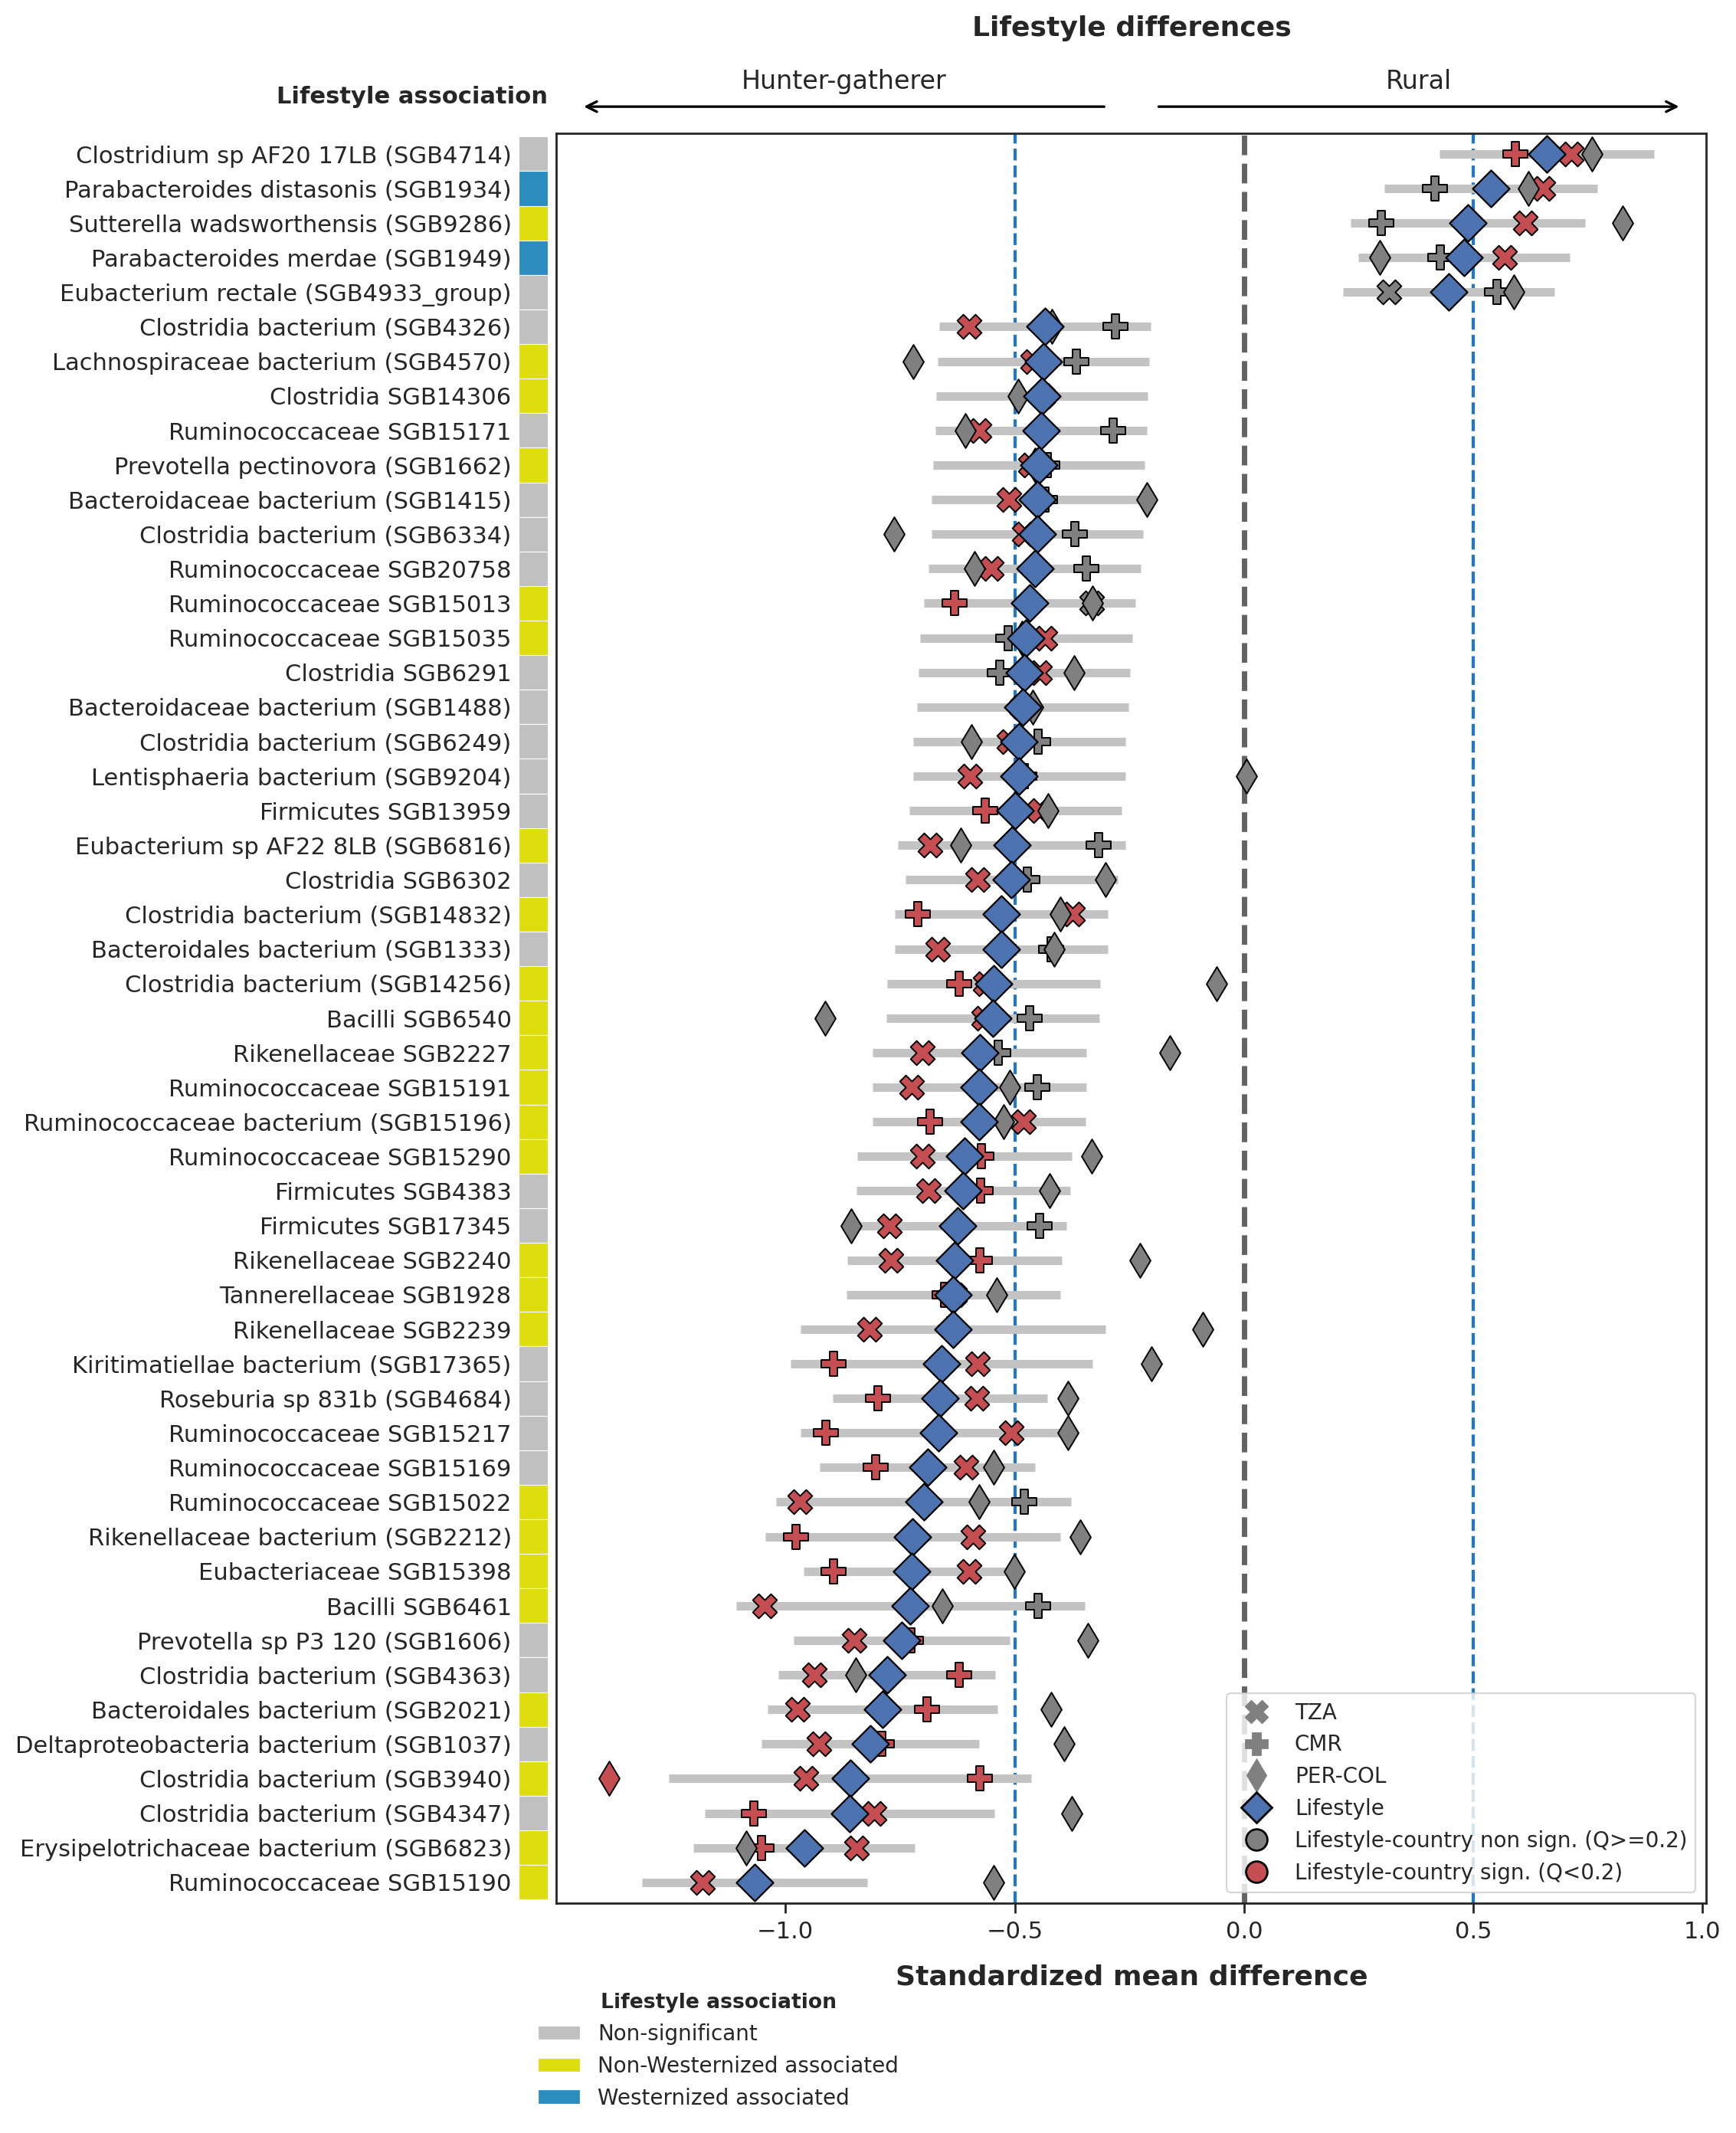

In [24]:
COUNTRY_COLUMNS = {'TZA': 'TZA', 'CMR': 'CMR', 'PER-COL': 'PER'}   # panel label -> column prefix

fig, (strip, ax) = plt.subplots(
    1, 2, figsize=(10, 15), dpi=200,
    gridspec_kw={'width_ratios': [0.025, 1], 'wspace': 0.015}
)

for y, (sgb, row) in enumerate(selected.iterrows()):
    strip.barh(y, 1, height=1, color=ASSOCIATION_COLORS[row['association']],
               edgecolor='white', linewidth=0.4)
    ax.plot([row['ci_low'], row['ci_high']], [y, y], color=CI_COLOR, linewidth=4,
            solid_capstyle='butt', zorder=1)
    for country, prefix in COUNTRY_COLUMNS.items():
        significant = row[f'{prefix}_Qvalue'] < Q_COUNTRY
        ax.scatter(row[f'{prefix}_Effect'], y, marker=COUNTRY_MARKERS[country], s=130,
                   color=SIGNIF_COLOR if significant else NONSIGNIF_COLOR,
                   edgecolors='black', linewidths=0.7, zorder=2)
    ax.scatter(row['RE_Effect'], y, marker='D', s=150, color=EFFECT_COLOR,
               edgecolors='black', linewidths=0.8, zorder=3)

ax.axvline(0, color='#636363', linestyle='--', linewidth=2.5, zorder=0)
for position in (-0.5, 0.5):
    ax.axvline(position, color='#1f77d0', linestyle='--', linewidth=1.5, zorder=0)

ax.set_ylim(-0.6, len(selected) - 0.4)
ax.invert_yaxis()
ax.set_yticks([])
ax.set_xlabel('Standardized mean difference', fontweight='bold', labelpad=10)

strip.set_ylim(ax.get_ylim())
strip.set_xlim(0, 1)
strip.set_xticks([])
strip.set_yticks(range(len(selected)))
strip.set_yticklabels(selected['label'])
strip.tick_params(axis='y', length=0)
for side in ('top', 'right', 'bottom', 'left'):
    strip.spines[side].set_visible(False)
strip.set_title('Lifestyle association', fontsize=11, fontweight='bold', loc='right', pad=14)

# Direction arrows above the panel.
ax.annotate('', xy=(0.02, 1.015), xytext=(0.48, 1.015), xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='black', linewidth=1.2))
ax.annotate('', xy=(0.98, 1.015), xytext=(0.52, 1.015), xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='black', linewidth=1.2))
ax.text(0.25, 1.025, 'Hunter-gatherer', transform=ax.transAxes, ha='center', fontsize=12)
ax.text(0.75, 1.025, 'Rural', transform=ax.transAxes, ha='center', fontsize=12)
ax.text(0.5, 1.055, 'Lifestyle differences', transform=ax.transAxes, ha='center',
        fontsize=13, fontweight='bold')

ax.legend(handles=[
    *[Line2D([], [], linestyle='', marker=COUNTRY_MARKERS[c], color=NONSIGNIF_COLOR,
             markersize=10, label=c) for c in COUNTRY_COLUMNS],
    Line2D([], [], linestyle='', marker='D', color=EFFECT_COLOR, markeredgecolor='black',
           markersize=10, label='Lifestyle'),
    Line2D([], [], linestyle='', marker='o', color=NONSIGNIF_COLOR, markeredgecolor='black',
           markersize=10, label=f'Lifestyle-country non sign. (Q>={Q_COUNTRY})'),
    Line2D([], [], linestyle='', marker='o', color=SIGNIF_COLOR, markeredgecolor='black',
           markersize=10, label=f'Lifestyle-country sign. (Q<{Q_COUNTRY})'),
], loc='lower right', frameon=True, fontsize=10)

strip_leg = strip.legend(handles=[Patch(facecolor=ASSOCIATION_COLORS[k], label=v)
                                  for k, v in ASSOCIATION_LABELS.items()],
                         title='Lifestyle association',
                         loc='upper left', bbox_to_anchor=(0.0, -0.04), frameon=False)
strip_leg.get_title().set_fontweight('bold')

plt.show()

## 6. Figure S9 — SGBs separating the three Tanzanian lifestyles

Every SGB detected in Tanzania is tested in six one-sided Mann-Whitney U tests, one per ordered
pair of lifestyles, and each set of p-values is FDR-corrected on its own. An SGB counts as enriched
in a lifestyle when it is significantly higher than *both* other lifestyles, and the strongest
`TOP_PER_LIFESTYLE` per lifestyle go into the heatmap.

`RANK_AS_PUBLISHED` controls how "strongest" is measured. The original ranking used, for the rural
and peri-urban candidates, a pair of q-values that did not match the pair used to select them;
keeping it reproduces the published panel, while `False` ranks each lifestyle by the two q-values
that define it and can change a few of the rows.

In [27]:
RANK_AS_PUBLISHED = True

tza_groups = groups[groups['country'] == 'TZA']
tza_abs = profiles[tza_groups.index]
tza_abs = tza_abs.loc[tza_abs.sum(axis=1) > 0]

by_lifestyle = {lifestyle: list(tza_groups.index[tza_groups['lifestyle'] == lifestyle])
                for lifestyle in LIFESTYLES}
CONTRASTS = [(a, b) for a in LIFESTYLES for b in LIFESTYLES if a != b]


def greater_than(values, higher, lower):
    """One-sided Mann-Whitney U p-value; 1.0 when both groups are constant and identical."""
    a, b = values[by_lifestyle[higher]], values[by_lifestyle[lower]]
    if set(a) == set(b) and len(set(a)) == 1:
        return 1.0
    return mannwhitneyu(a, b, alternative='greater').pvalue


pvalues = pd.DataFrame({f'{a}>{b}': tza_abs.apply(greater_than, axis=1, higher=a, lower=b)
                        for a, b in CONTRASTS})
qvalues = pvalues.apply(lambda column: fdrcorrection(column)[1])
qvalues.head()

,Hunter-gatherer>Rural,Hunter-gatherer>Peri-urban,Rural>Hunter-gatherer,Rural>Peri-urban,Peri-urban>Hunter-gatherer,Peri-urban>Rural
SGB1626,1.000000,2.407020e-19,0.641090,4.149478e-23,1.00000,1.0
SGB4290,0.415275,3.282096e-02,1.000000,2.067323e-01,1.00000,1.0
SGB5117,1.000000,1.000000e+00,0.660215,6.603930e-01,0.61914,1.0
SGB4260,1.000000,8.265415e-01,0.660215,3.130574e-02,1.00000,1.0
SGB15234,1.000000,4.295511e-02,0.666996,5.473292e-05,1.00000,1.0


In [28]:
def enriched_in(lifestyle):
    """SGBs significantly higher in one lifestyle than in both others, strongest first."""
    others = [other for other in LIFESTYLES if other != lifestyle]
    defining = [f'{lifestyle}>{other}' for other in others]
    significant = (qvalues[defining] < Q_TZA).all(axis=1)

    ranking_key = defining
    if RANK_AS_PUBLISHED:
        ranking_key = {
            'Hunter-gatherer': ['Hunter-gatherer>Rural', 'Hunter-gatherer>Peri-urban'],
            'Rural': ['Hunter-gatherer>Rural', 'Rural>Peri-urban'],
            'Peri-urban': ['Hunter-gatherer>Peri-urban', 'Rural>Peri-urban'],
        }[lifestyle]

    ranked = qvalues.loc[significant, ranking_key].mean(axis=1).sort_values()
    return list(ranked.index[:TOP_PER_LIFESTYLE])


species2show = []
for lifestyle in LIFESTYLES:
    enriched = enriched_in(lifestyle)
    species2show += [sgb for sgb in enriched if sgb not in species2show]
    print(f'{lifestyle}: {(qvalues[[f"{lifestyle}>{o}" for o in LIFESTYLES if o != lifestyle]] < Q_TZA).all(axis=1).sum()}'
          f' enriched SGBs, {len(enriched)} shown')

heatmap = tza_abs.loc[species2show]
heatmap = heatmap.loc[:, heatmap.sum() > 0]
heatmap.index = [LABELS.get(sgb, sgb) for sgb in heatmap.index]
heatmap.shape

Hunter-gatherer: 243 enriched SGBs, 10 shown
Rural: 85 enriched SGBs, 10 shown
Peri-urban: 164 enriched SGBs, 10 shown


(30, 352)

/shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/miniconda3/envs/wnw/lib/python3.8/site-packages/seaborn/matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


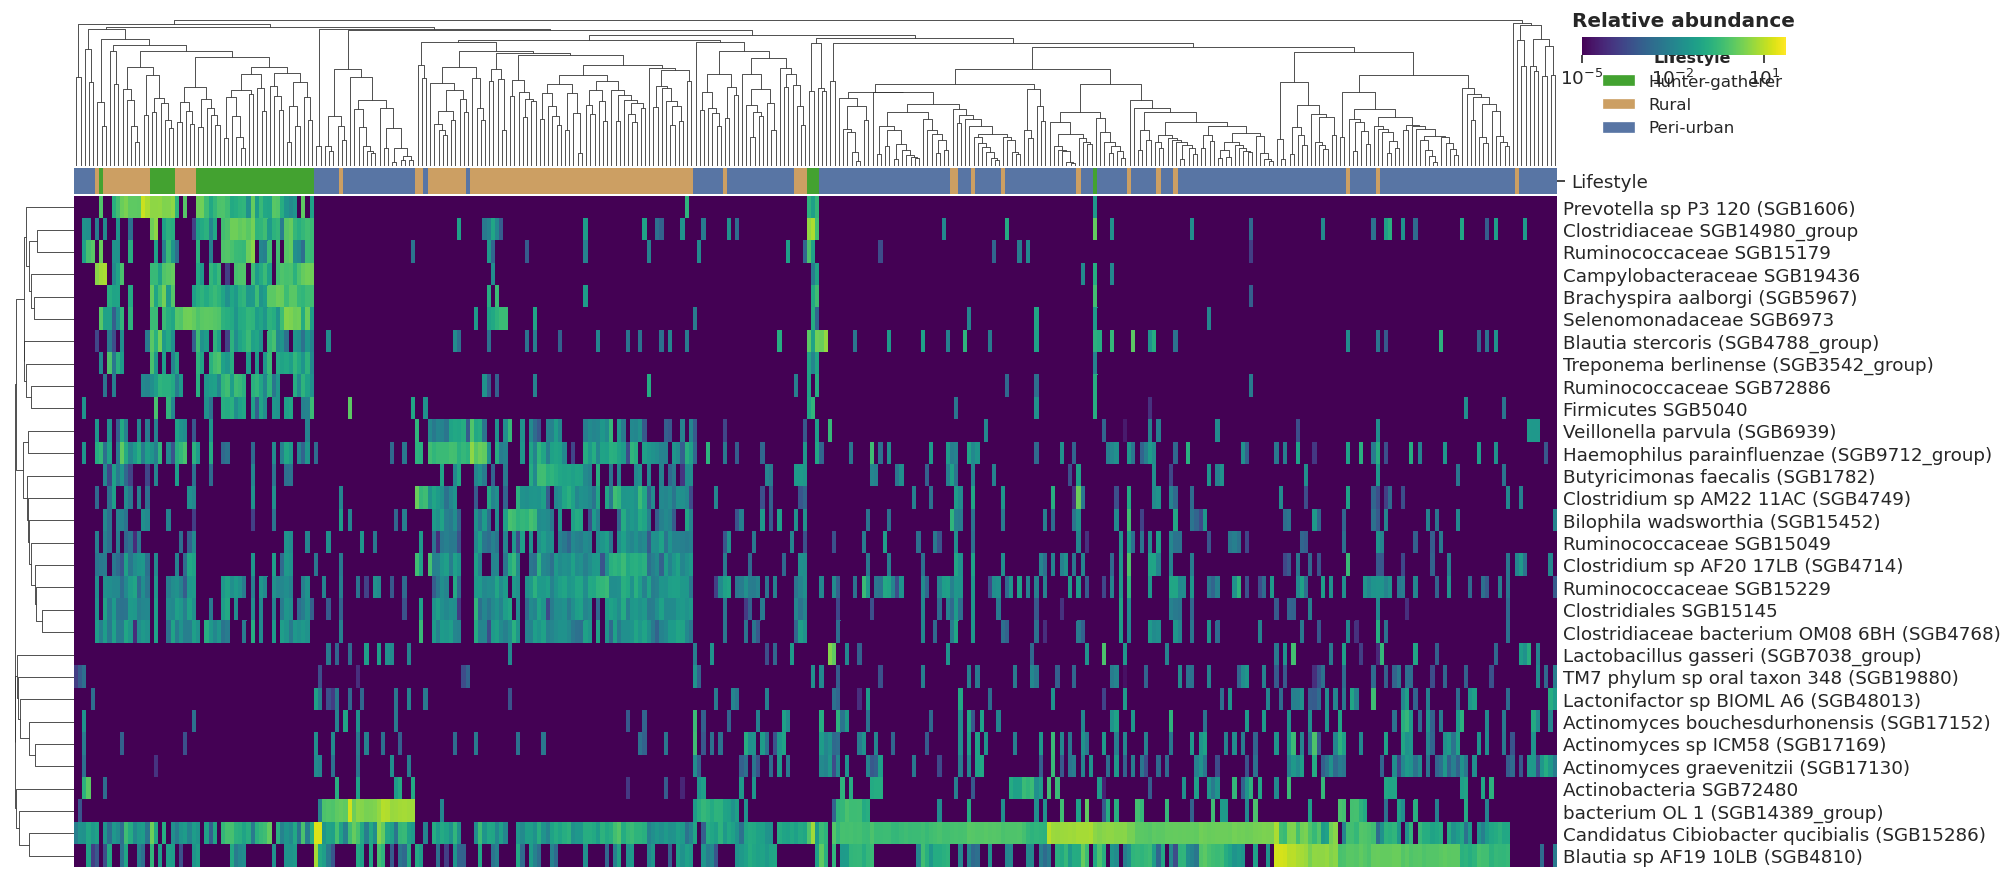

In [33]:
import copy

colormap = copy.copy(plt.cm.get_cmap('viridis'))
colormap.set_bad(colormap(0.0))     # zeros are masked by LogNorm; draw them as the floor colour

column_colors = tza_groups.loc[heatmap.columns, 'lifestyle'].map(LIFESTYLE_COLORS)
column_colors.name = 'Lifestyle'

grid = sns.clustermap(
    heatmap, norm=LogNorm(vmin=1e-5, vmax=50), cmap=colormap, metric='braycurtis',
    col_colors=column_colors, row_cluster=True, col_cluster=True, figsize=(17, 7.5),
    xticklabels=False, yticklabels=True, dendrogram_ratio=(0.04, 0.18),
    cbar_pos=(0.78, 0.93, 0.1, 0.02), cbar_kws={'orientation': 'horizontal'},
    rasterized=True)

grid.ax_heatmap.set_xlabel('')
grid.ax_heatmap.set_ylabel('')
grid.ax_heatmap.tick_params(axis='y', length=0)
grid.ax_cbar.set_title('Relative abundance', fontsize=12, fontweight='bold')

leg = grid.ax_col_dendrogram.legend(
    handles=[Patch(facecolor=LIFESTYLE_COLORS[lifestyle], label=lifestyle)
             for lifestyle in LIFESTYLES],
    title='Lifestyle',
    loc='lower left', bbox_to_anchor=(1.02, 0.1), frameon=False)
leg.get_title().set_fontweight('bold')

plt.show()